# COMP8325 Week 3 Workshop
# Supervised Learning: Regression & Classification

In this week's workshop, we will learn about **supervised machine learning** wherein an annotated data having input-output pair is given to us to train a machine learning model. The trained model then can be used to make predictions on **unseen** data (or test set).

### Dataset Description

You are given `houses_portland.csv` file which contains columns for `area` of a house, number of `bedroom`s in a house, and `price`. The goal is to build a model which can predict `price` of a house given number of `bedroom`s and `area`. First we will load the dataset and find relationship between variables.

In [8]:
# Import the commonly-used modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

*Note:* The `%matplotlib inline` code makes sure that the matplotlib plots are shown directly below the code cells instead of a new cell.

In [9]:
# Load the dataset
data = pd.read_csv("C:\\Users\\Hitomi\\OneDrive\\Desktop\\COMP8325 Applications of Artificial Intelligence for Cyber Security\\Workshop Week 3\\houses_portland.csv")
print("data size: "+str(data.shape))
data.head()

data size: (47, 3)


,area,bedroom,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


## Task 1: Ordinary linear regression model on one-dimensional feature/variable

### Let's show a demo first

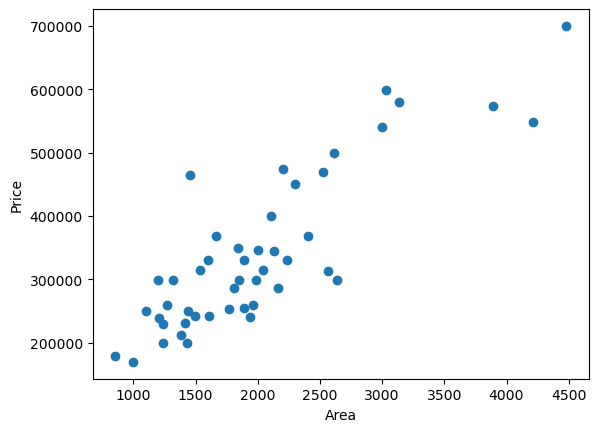

In [10]:
# Visually explore the relationship between "area" and "price"
X = data['area'].values
y = data['price'].values
plt.scatter(X, y)
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

### Split data into `train` and `test` using the [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) method from sklearn library.

In [11]:
# Split data
from sklearn import model_selection as ms
X_train, X_test, y_train, y_test = ms.train_test_split(X, y, test_size=0.2)
X_train = np.reshape(X_train, (-1, 1))  # change from 1D array to 2D array
X_test = np.reshape(X_test, (-1, 1))
print("training data feature shape:", X_train.shape)
print("training data label shape:", y_train.shape)
print("test data feature space shape:", X_test.shape)
print("test data label shape:", y_test.shape)

training data feature shape: (37, 1)
training data label shape: (37,)
test data feature space shape: (10, 1)
test data label shape: (10,)


Looking at the shape of train and test sets, we can say that out of total 47 samples, 37 samples are in training and the remaining 10 samples are in test. Look at the documentation of `train_test_split` function to find out whether data is shuffled or not during the split operation.

### Model Development (or model training)

In [12]:
# Build linear regression model
from sklearn import linear_model as lm
ordinaryLRmodel = lm.LinearRegression()
ordinaryLRmodel.fit(X_train, y_train)

LinearRegression()

In [7]:
# Print the coefficients
print("coefficient:", ordinaryLRmodel.coef_)
print("intercept:", ordinaryLRmodel.intercept_)

coefficient: [141.31617757]
intercept: 56735.939801174216


What is an Intercept? How do you define coefficient? Can you comment on the importance of coefficient and intercept? What does these numbers signify in terms of price of a house?

Intercept:
The intercept is the predicted value of the target variable when all input features are zero. In this model, it represents the estimated base price of a house when the area is zero.

Coefficient:
The coefficient represents how much the house price changes when the feature increases by one unit. In this case, the coefficient shows how much the price increases for each additional square unit of area.

If the coefficient is positive, it means that as the area increases, the house price also increases. The intercept and coefficient together form the regression equation that predicts house prices based on the area.

### Plotting regression line

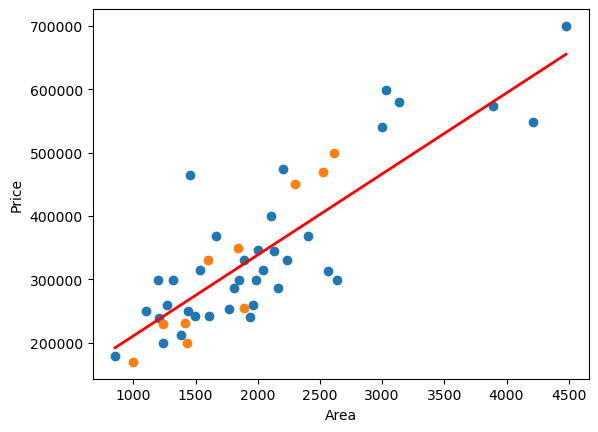

In [8]:
# Plot the model
x_line=[X.min(), X.max()]
xmin = np.reshape(X.min(), (-1, 1)) # reshape
xmax = np.reshape(X.max(), (-1, 1))
y_line=[ordinaryLRmodel.predict(xmin), ordinaryLRmodel.predict(xmax)]
plt.plot(x_line, y_line, 'r', lw=2)
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

### Model Evaluation (on test set)

In [13]:
# Prediction/Testing
y_pred = ordinaryLRmodel.predict(X_test)
y_pred

array([190367.26712514, 274572.98852042, 340940.73778213, 409931.71823994,
       251750.87711423, 241126.79076996, 588836.08581497, 665959.08298074,
       362188.91047066, 264342.38685558])

Refer to https://en.wikipedia.org/wiki/Coefficient_of_determination for more details about coefficient of determination $r^2$

In [10]:
# Performance metrics
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error
print('Mean squared error: %.2f' %mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f' %r2_score(y_test, y_pred))

Mean squared error: 3116176014.75
Coefficient of determination: 0.76


Comment on the model performance in terms of evaluation metrics? 

The Mean Squared Error (MSE) measures the average squared difference between the predicted and actual house prices. A smaller MSE indicates better model performance.

The R² score indicates how well the model explains the variance in the data. An R² value close to 1 means the model explains most of the variation in house prices. Therefore, a lower MSE and higher R² suggest that the linear regression model performs well in predicting house prices.

## Task 2: Ordinary linear regression model on multi-dimensional features/variables

In [14]:
# Data preparation
X = data[['area', 'bedroom']].values
y = data['price'].values

### Split data into training and testing sets

In [22]:
# Write your code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training data feature shape:", X_train.shape)
print("training data label shape:", y_train.shape)
print("test data feature shape:", X_test.shape)
print("test data label shape:", y_test.shape)

training data feature shape: (37, 2)
training data label shape: (37,)
test data feature shape: (10, 2)
test data label shape: (10,)


### Build linear regression model

In [23]:
# Write your code here
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Check model coefficients and comment

In [24]:
# Write your code here
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [   143.21853204 -13512.56442597]
Intercept: 84763.622522194


The coefficients show the contribution of each feature (area and bedroom) to the house price prediction. A larger coefficient indicates that the feature has a stronger impact on price. The intercept represents the predicted price when all features are zero.

### Do model predictions on test set

In [25]:
# Write your code here
y_pred = model.predict(X_test)
print(y_pred)

[405995.94117864 340351.83108993 253038.54895937 216088.16769291
 601346.01888191 221673.69044249 314908.95480087 464808.73543314
 460368.96093988 201766.31448886]


### Get model scores in terms of MSE and $r^2$ scores

In [26]:
# Write your code here
from sklearn.metrics import mean_squared_error, r2_score

print("Mean squared error:", mean_squared_error(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))

Mean squared error: 8610424544.77767
R2 score: 0.5148848812741442


## Task 3: Nearest neighbors based classification

### Data preprocessing

In [28]:
# Import the commonly-used modules
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv("C:\\Users\\Hitomi\\OneDrive\\Desktop\\COMP8325 Applications of Artificial Intelligence for Cyber Security\\Workshop Week 3\\titanic.csv")
print("data size: "+str(data.shape))
data.head()

data size: (891, 12)


,PassengerId,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass,Survived
0,1,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,1
4,5,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3,0


In [18]:
# size of the data
print("(row, column):",data.shape)

(row, column): (891, 12)


In [29]:
# check for missing values
data.isnull().sum()

PassengerId      0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Pclass           0
Survived         0
dtype: int64

In [30]:
# one option is to just simply drop rows with any missing values
data_no_missing_value=data.dropna()
print("(row, column) after dropping missing values:\n",data_no_missing_value.shape)

(row, column) after dropping missing values:
 (183, 12)


In [34]:
# get one column from the data
data_name=data_no_missing_value["Name"]
data_name

1      Cumings, Mrs. John Bradley (Florence Briggs Th...
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
6                                McCarthy, Mr. Timothy J
10                       Sandstrom, Miss. Marguerite Rut
11                              Bonnell, Miss. Elizabeth
                             ...                        
871     Beckwith, Mrs. Richard Leonard (Sallie Monypeny)
872                             Carlsson, Mr. Frans Olof
879        Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)
887                         Graham, Miss. Margaret Edith
889                                Behr, Mr. Karl Howell
Name: Name, Length: 183, dtype: object

In [35]:
# get three columns from the data
data_sex_age_survived=data_no_missing_value[['Sex', 'Age', 'Survived']]
data_sex_age_survived

,Sex,Age,Survived
1,female,38.0,1
3,female,35.0,1
6,male,54.0,0
10,female,4.0,1
11,female,58.0,1
...,...,...,...
871,female,47.0,1
872,male,33.0,0
879,female,56.0,1
887,female,19.0,1


In [36]:
# encode categorical attributes
data_sex_age_survived['Sex']= data_sex_age_survived.Sex.astype('category').cat.codes
data_sex_age_survived

C:\Users\Hitomi\AppData\Local\Temp\ipykernel_20504\3470465631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sex_age_survived['Sex']= data_sex_age_survived.Sex.astype('category').cat.codes


,Sex,Age,Survived
1,0,38.0,1
3,0,35.0,1
6,1,54.0,0
10,0,4.0,1
11,0,58.0,1
...,...,...,...
871,0,47.0,1
872,1,33.0,0
879,0,56.0,1
887,0,19.0,1


### Build model and perform evaluation

In [37]:
# define X and y
feature_columns=['Sex', 'Age']
X=data_sex_age_survived[feature_columns]
y=data_sex_age_survived.Survived
print(X.head())
print(y.head())

    Sex   Age
1     0  38.0
3     0  35.0
6     1  54.0
10    0   4.0
11    0  58.0
1     1
3     1
6     0
10    1
11    1
Name: Survived, dtype: int64


In [38]:
# train/test data split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [39]:
# train a 1-NN classifier
from sklearn import neighbors
clf = neighbors.KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [40]:
# predict the test data
y_pred=clf.predict(X_test)
y_pred

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1])

In [41]:
# calculate testing accuracy
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred))

0.782608695652174


### Now, let's do the task

In [42]:
# Load the dataset
data = pd.read_csv("C:\\Users\\Hitomi\\OneDrive\\Desktop\\COMP8325 Applications of Artificial Intelligence for Cyber Security\\Workshop Week 3\\titanic.csv")
data.head()

,PassengerId,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass,Survived
0,1,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,1
4,5,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3,0


In [43]:
# delete the attribute "Cabin"
data = data.drop(columns=["Cabin"])

In [44]:
# fill missing values with the mean age
data["Age"] = data["Age"].fillna(data["Age"].mean())

In [45]:
# drop rows with any missing values (the "Embarked" atrribute)
data = data.dropna()

In [46]:
# "PassengerId", "Name" and "Ticket" are not suitable for features. Select all other attributes to form a data set.
X = data.drop(columns=["PassengerId", "Name", "Ticket", "Survived"])
y = data["Survived"]

In [47]:
# encode the categorical attributes where applicable
X = pd.get_dummies(X)

In [55]:
# build a 1-NN classification model where "Survived" is the prediction target
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y)

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7713004484304933


### More advanced tasks

Manually try other k values, e.g., 2, 3, 5, 10, the accuracy comparison

*Hints:* Put all values of k in a list. For each value of k instantiate a KNN classifier, and show its accuracy with a plot.

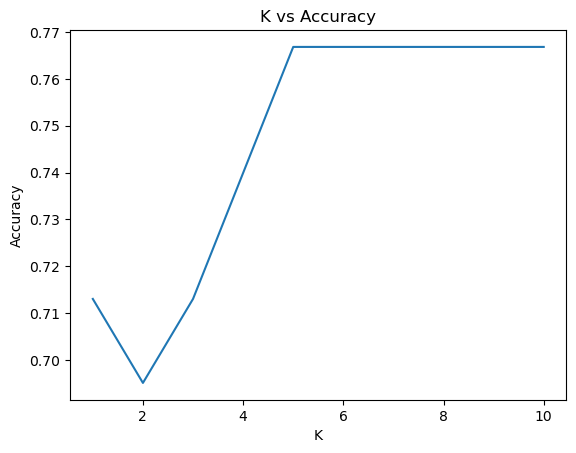

In [56]:
# write your code here
import matplotlib.pyplot as plt

k_values = [1,2,3,5,10]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

plt.plot(k_values, accuracies)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

Use 10-fold cross-validation (CV) for the kNN parameter k = 3. Output the mean and standard deviation of the accuracy for each fold.

*Hint:* To do this, make use of the `cross_val_score` function of `sklearn.model_selection`. 

In [57]:
# write your code here
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=3)

scores = cross_val_score(knn, X, y, cv=10)

print("Accuracy for each fold:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Accuracy for each fold: [0.64044944 0.6741573  0.73033708 0.75280899 0.78651685 0.73033708
 0.76404494 0.71910112 0.60674157 0.76136364]
Mean accuracy: 0.7165858018386109
Standard deviation: 0.05523322909594682


Recall that the purpose of using a 10-fold, or in general k-fold, validation (note the k here is different from the k in kNN) is to choose the best hyperparameter. The hyperparameter here is k in kNN. That is we want to choose how many neighbors to consider. To do this we need to perform 10-fold cross validation over multiple values of k. Let us assume `k = [1,2,3,5,7,9,10]`.

Luckily the function `GridSearchCV` class from `sklearn.model_selection` can do this automatically for us. To use this class you need to pass the above values of k as `parameters` which is a dictionary construct. Please see the documentation of `GridSearchCV` on how to pass this for the kNN classifier.

What is the best parameter?


In [58]:
# write your code here
from sklearn.model_selection import GridSearchCV

param_grid = {"n_neighbors":[1,2,3,5,7,9,10]}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10)

grid.fit(X, y)

print("Best parameter:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameter: {'n_neighbors': 7}
Best score: 0.7188712972420838


## Task 4: Build a decision tree model for the above classification task

Use `DecisionTreeClassifier` with default settings for this task. Output the accuracy or classification report. 

Does decision tree classifier perform better than kNN?

In [59]:
# Write your code here

# model import and instantiation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7488789237668162
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       140
           1       0.68      0.63      0.65        83

    accuracy                           0.75       223
   macro avg       0.73      0.72      0.73       223
weighted avg       0.75      0.75      0.75       223



The decision tree classifier builds a tree structure that splits the data based on feature values. The performance can be compared with the kNN classifier by evaluating their accuracy. If the decision tree accuracy is higher, it performs better for this dataset; otherwise, kNN performs better. In my code, accuracy are almost same : kNN = 0.7713004484304933 | The decision tree = 0.7488789237668162 while kNN could be described as slightly better model.